Accuracy score:  0.625
Precision score:  0.5916951561508883
Recall:  0.625
F1_score:  0.6050710391108316
Confusion matrix
 [[ 0  1  1  0  0  0]
 [ 0  0  8  3  0  0]
 [ 0  1 84 29  2  0]
 [ 0  0 25 74  8  0]
 [ 0  0  4 16 12  1]
 [ 0  0  0  2  1  0]]
Classification report

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.69      0.72      0.71       116
           6       0.60      0.69      0.64       107
           7       0.52      0.36      0.43        33
           8       0.00      0.00      0.00         3

    accuracy                           0.62       272
   macro avg       0.30      0.30      0.30       272
weighted avg       0.59      0.62      0.61       272

                 Feature  Importance
10               alcohol    0.151170
9              sulphates    0.112418
1       volatile acidity    0.104158
6   total sulfur dioxide    0.101988

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

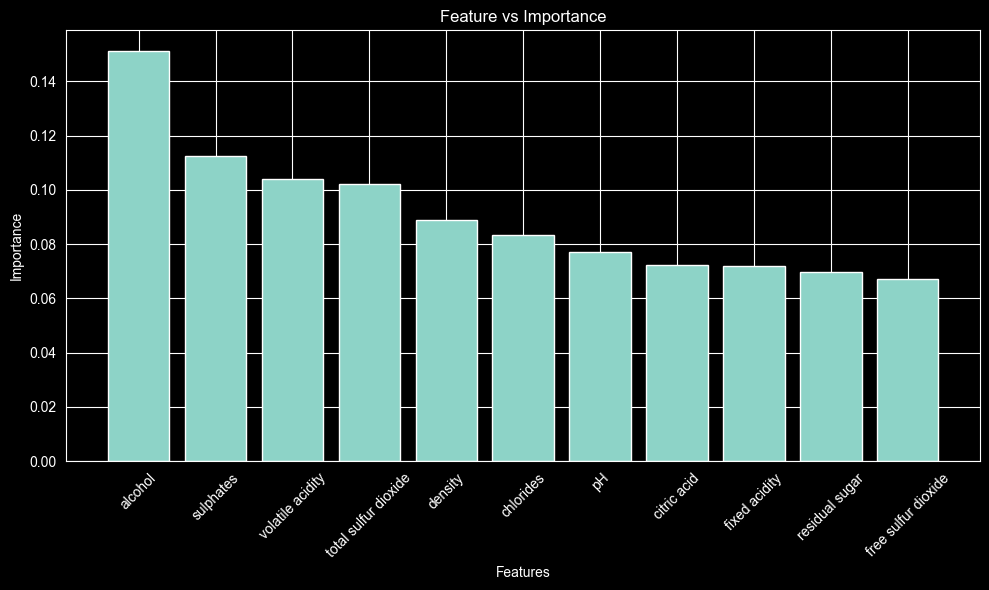

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,precision_score,recall_score,classification_report
import matplotlib.pyplot as plt

# Load the shared clean data and split data
x_train=pd.read_csv("../output/x_train.csv")
x_test=pd.read_csv("../output/x_test.csv")
y_train=pd.read_csv("../output/y_train.csv").squeeze()
y_test=pd.read_csv("../output/y_test.csv").squeeze()
# we use squeeze for y_train and y_test because both of these files
# only have 1 column
# so .squeeze() helps us convert from 1 column DataFrame to a series
# this one helps us get the target variable as a 1-dimension
# because we only need values, makes more cleaner

# create random_forest_model
random_forest_model=RandomForestClassifier(n_estimators=100,random_state=42)

# train the random_forest model
# we let random forest model learn from training dataset in order to predict
# on unseen data
random_forest_model.fit(x_train,y_train)

#predict
predicted_random_forest_model=random_forest_model.predict(x_test)

# evaluate the model
accuracy=accuracy_score(y_test,predicted_random_forest_model)
precision=precision_score(y_test,predicted_random_forest_model,average="weighted")
recall=recall_score(y_test,predicted_random_forest_model,average="weighted")
f1=f1_score(y_test,predicted_random_forest_model,average="weighted")
confusion_matrix_value=confusion_matrix(y_test,predicted_random_forest_model)

print("Accuracy score: ",accuracy)
print("Precision score: ",precision)
print("Recall: ",recall)
print("F1_score: ",f1)
print("Confusion matrix\n",confusion_matrix_value)
print("Classification report\n")
print(classification_report(y_test,predicted_random_forest_model))

# feature importance
importances=random_forest_model.feature_importances_
feature_importances=pd.DataFrame({
    "Feature":x_train.columns,
    "Importance":importances
})
feature_importances=feature_importances.sort_values(by="Importance",ascending=False)
print(feature_importances)

plt.figure(figsize=(10,6))
plt.title("Feature vs Importance")
plt.bar(feature_importances["Feature"],feature_importances["Importance"])
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.tight_layout()
plt.show()









